In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

1. DATA IMPORT

In [ ]:
import pandas as pd

telco = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


2. DATA CLEANING

2.1. Check Missing Value

In [ ]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


No missing value.

2.2. Check Data Type

In [ ]:
# Convert 'Total Charges' column to numeric
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco['TotalCharges']


,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


2.3. Check Data Consistency

In [ ]:
# Check Missing Values
nan_count = telco.isna().sum()
print(nan_count)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
telco[telco['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
# Drop rows where TotalCharges is NaN
telco = telco.dropna(subset=['TotalCharges'])

In [ ]:
nan_count = telco.isna().sum()
print(nan_count)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# Check rows where InternetService is 'No' but any add-on services are not 'No internet service'
inconsistent_internet_service_addons = []
for index, row in telco.iterrows():
    if row['InternetService'] == 'No':
        if (row['OnlineSecurity'] != 'No internet service' or
            row['OnlineBackup'] != 'No internet service' or
            row['DeviceProtection'] != 'No internet service' or
            row['TechSupport'] != 'No internet service' or
            row['StreamingTV'] != 'No internet service' or
            row['StreamingMovies'] != 'No internet service'):
            inconsistent_internet_service_addons.append(row.to_dict())

In [ ]:
inconsistent_internet_service_addons_df = pd.DataFrame(inconsistent_internet_service_addons)

In [ ]:
if not inconsistent_internet_service_addons_df.empty:
    print(inconsistent_internet_service_addons_df[['customerID', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                           'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']])
    print("Number of inconsistent internet service rows:", len(inconsistent_internet_service_addons_df))
else:
    print("No inconsistent internet service rows found.")

No inconsistent internet service rows found.


In [ ]:
# Check rows where InternetService is not 'No' but any add-on services are 'No internet service'
inconsistent_rows = []
for index, row in telco.iterrows():
    if row['InternetService'] != 'No':
        if (row['OnlineSecurity'] == 'No internet service' or
            row['OnlineBackup'] == 'No internet service' or
            row['DeviceProtection'] == 'No internet service' or
            row['TechSupport'] == 'No internet service' or
            row['StreamingTV'] == 'No internet service' or
            row['StreamingMovies'] == 'No internet service'):
            inconsistent_rows.append(row.to_dict())

In [ ]:
inconsistent_internet_service_rows = []

In [ ]:
inconsistent_df = pd.DataFrame(inconsistent_rows)

In [ ]:
if not inconsistent_df.empty:
    print(inconsistent_df[['customerID', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                           'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']])
    print("Number of inconsistent rows:", len(inconsistent_df))
else:
    print("No inconsistent rows found.")


No inconsistent rows found.


No values of internet service and add-on services is inconsistent.

In [ ]:
# Check rows where PhoneService is 'No' but MultipleLines is not 'No phone service'
inconsistent_phoneservice_rows = []
for index, row in telco.iterrows():
    if row['PhoneService'] == 'No':
        if row['MultipleLines'] != 'No phone service':
          inconsistent_phoneservice_rows.append(row.to_dict())

In [ ]:
inconsistent_phoneservice_df = pd.DataFrame(inconsistent_phoneservice_rows)

In [ ]:
if not inconsistent_phoneservice_df.empty:
    print(inconsistent_phoneservice_df[['customerID', 'PhoneService', 'MultipleLines']])
    print("Number of inconsistent phoneservice rows:", len(inconsistent_phoneservice_df))
else:
    print("No inconsistent phone service rows found.")

No inconsistent phone service rows found.


In [ ]:
# Check rows that PhoneService is 'Yes' but MultipleLines is 'No phone service'
inconsistent_phoneservice_rows_yes = []
for index, row in telco.iterrows():
    if row['PhoneService'] == 'Yes':
        if row['MultipleLines'] == 'No phone service':
          inconsistent_phoneservice_rows_yes.append(row.to_dict())

In [ ]:
inconsistent_phoneservice_rows_yes_df = pd.DataFrame(inconsistent_phoneservice_rows_yes)

In [ ]:
if not inconsistent_phoneservice_rows_yes_df.empty:
    print(inconsistent_phoneservice_rows_yes_df[['customerID', 'PhoneService', 'MultipleLines']])
else:
    print("No inconsistent phone service rows found.")

No inconsistent phone service rows found.


No values of phone service and multiple lines are inconsistent.

2.4. Check Duplicate Values

In [ ]:
# Check duplicate rows
telco.duplicated().sum()

np.int64(0)

No dulicate rows.

In [ ]:
# Check duplicate customer ID
telco[telco.duplicated(subset='customerID', keep=False)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


No duplicate customer ID.

In [ ]:
# Check value counts of categorical columns
telco['Partner'].value_counts()

,count
Partner,
No,3639
Yes,3393


In [ ]:
telco['gender'].value_counts()

,count
gender,
Male,3549
Female,3483


In [ ]:
telco['Dependents'].value_counts()

,count
Dependents,
No,4933
Yes,2099


In [ ]:
telco['PhoneService'].value_counts()

,count
PhoneService,
Yes,6352
No,680


In [ ]:
telco['MultipleLines'].value_counts()

,count
MultipleLines,
No,3385
Yes,2967
No phone service,680


In [ ]:
telco['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2416
No,1520


In [ ]:
telco['OnlineSecurity'].value_counts()

,count
OnlineSecurity,
No,3497
Yes,2015
No internet service,1520


In [ ]:
telco['OnlineBackup'].value_counts()

,count
OnlineBackup,
No,3087
Yes,2425
No internet service,1520


In [ ]:
telco['DeviceProtection'].value_counts()

,count
DeviceProtection,
No,3094
Yes,2418
No internet service,1520


In [ ]:
telco['TechSupport'].value_counts()

,count
TechSupport,
No,3472
Yes,2040
No internet service,1520


In [ ]:
telco['StreamingMovies'].value_counts()

,count
StreamingMovies,
No,2781
Yes,2731
No internet service,1520


In [ ]:
telco['StreamingTV'].value_counts()

,count
StreamingTV,
No,2809
Yes,2703
No internet service,1520


In [ ]:
telco['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1685
One year,1472


In [ ]:
telco['PaperlessBilling'].value_counts()

,count
PaperlessBilling,
Yes,4168
No,2864


In [ ]:
telco['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1604
Bank transfer (automatic),1542
Credit card (automatic),1521


In [ ]:
telco['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


Categorical columns contain no duplicates or spelling errors.

2.5. Check Outliers

<Axes: >

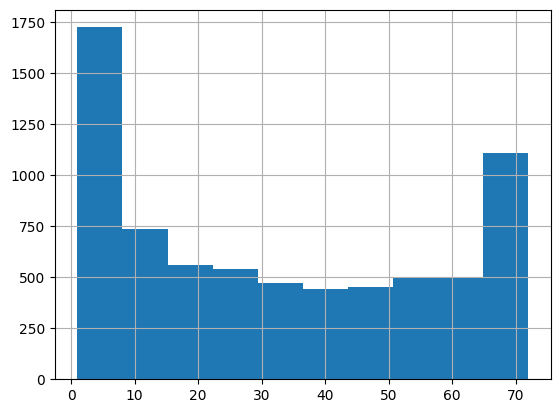

In [ ]:
# Check Outliers of Tenure
telco['tenure'].hist()

Tenure column has no outliers.

<Axes: >

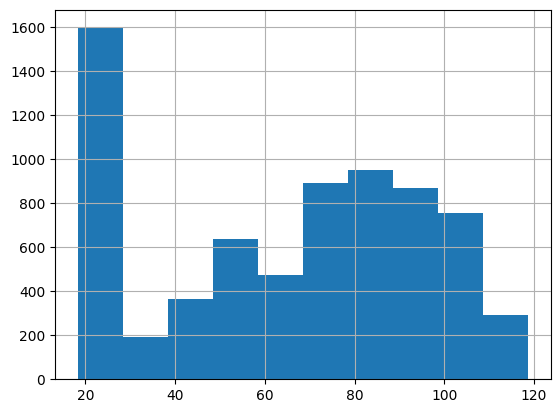

In [ ]:
# Check Outliers of MonthlyCharges
telco['MonthlyCharges'].hist()

MonthlyCharges column has no outliers.

<Axes: >

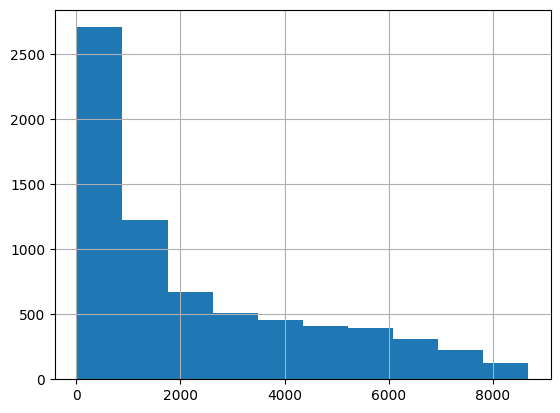

In [ ]:
# Check Outliers of TotalCharges
telco['TotalCharges'].hist()

TotalCharges Column has no outliers.

# 3. Exploratory Data Analysis

3.1. Basic Statistic

In [ ]:
#Check basic statistic
telco.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


3.2. Churn Analysis

Overall Churn Rate

In [ ]:
# Convert 'Churn' column to numeric
telco['Churn'] = telco['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
# Calculate overall Churn Rate
overall_churn_rate = telco['Churn'].mean() * 100
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")

Overall Churn Rate: 26.58%


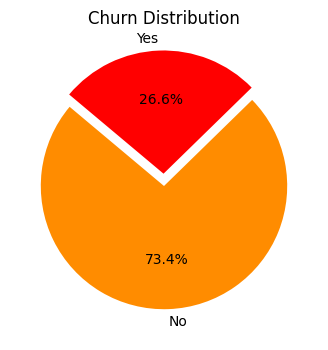

In [ ]:
# Visualize overall Churn Rate
# Get churn counts
churn_counts = telco['Churn'].value_counts()

# Define your mapping
churn_labels = {0: 'No', 1: 'Yes'}

# Define explode (still exploding the "Yes" slice)
explode = (0, 0.1)

# Get values in correct order
values = [churn_counts.get(0, 0), churn_counts.get(1, 0)]
labels = ['No', 'Yes']

# Plot the pie chart
plt.figure(figsize=(4, 4))
plt.pie(values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=['darkorange','red'],
        explode=explode)
plt.title('Churn Distribution')
plt.show()

Churn by Customer Segment

In [ ]:
# Calculate Churn Rate by Gender
churn_by_gender = telco.groupby('gender')['Churn'].mean() * 100
print("Churn Rate by Gender:")
print(churn_by_gender)

Churn Rate by Gender:
gender
Female    26.959518
Male      26.204565
Name: Churn, dtype: float64


No significant difference in churn rate by gender.

In [ ]:
# Calculate churn rate by age
churn_by_age = telco.groupby('SeniorCitizen')['Churn'].mean() * 100
print("Churn Rate by Age:")
print(churn_by_age)

Churn Rate by Age:
SeniorCitizen
0    23.650255
1    41.681261
Name: Churn, dtype: float64


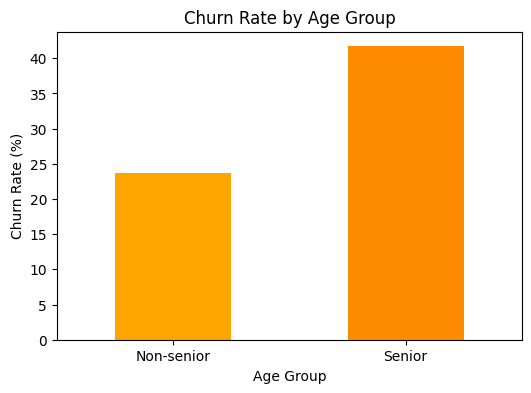

In [ ]:
# Visaulize churn rate by age groups
plt.figure(figsize=(6, 4))
churn_by_age.plot(kind='bar', color= ['orange', 'darkorange'])
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(ticks=[0, 1], labels=['Non-senior', 'Senior'], rotation=0)
plt.show()

Seniors have a much higher churn rate (41.7%) compared to younger customers (23.6%).

In [ ]:
# Calculate churn rate by partner
churn_by_partner = telco.groupby('Partner')['Churn'].mean() * 100
print("Churn Rate by Partner:")
print(churn_by_partner)

Churn Rate by Partner:
Partner
No     32.976092
Yes    19.717065
Name: Churn, dtype: float64


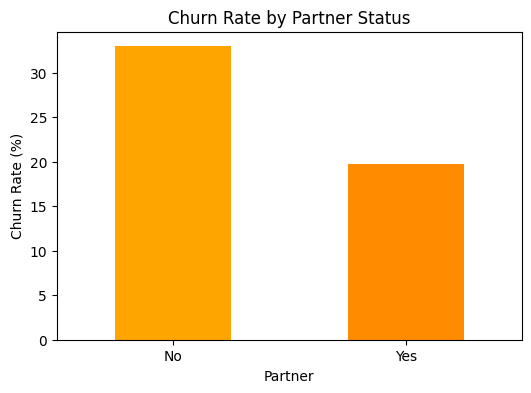

In [ ]:
# Visualize churn rate by partner
plt.figure(figsize=(6, 4))
churn_by_partner.plot(kind='bar', color= ['orange', 'darkorange'])
plt.title('Churn Rate by Partner Status')
plt.xlabel('Partner')
plt.ylabel('Churn Rate (%)')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], rotation=0)
plt.show()

Customers without a partner tend to churn more.

In [ ]:
# Calculate Churn Rate by Dependants
churn_by_dependents = telco.groupby('Dependents')['Churn'].mean() * 100
print("Churn Rate by Dependents:")
print(churn_by_dependents)

Churn Rate by Dependents:
Dependents
No     31.279140
Yes    15.531205
Name: Churn, dtype: float64


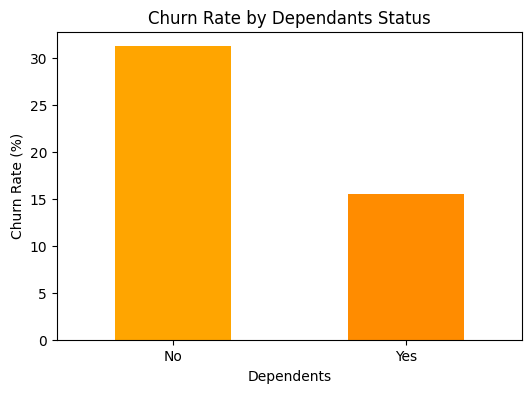

In [ ]:
# Visualize churn rate by dependants
plt.figure(figsize=(6, 4))
churn_by_dependents.plot(kind='bar', color= ['orange', 'darkorange'])
plt.title('Churn Rate by Dependants Status')
plt.xlabel('Dependents')
plt.ylabel('Churn Rate (%)')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], rotation=0)
plt.show()

Customers without dependents are twice as likely to churn compared to those with dependents.



Churn rate by Service Used:

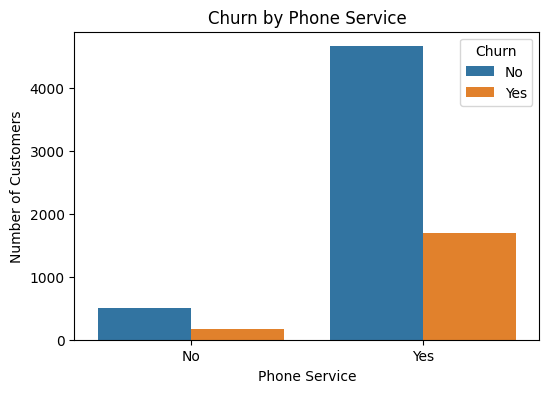

In [ ]:
# Churn By Phone Service

plt.figure(figsize=(6,4))
sns.countplot(data=telco, x='PhoneService', hue='Churn')
plt.title('Churn by Phone Service')
plt.xlabel('Phone Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

In [ ]:
# Calculate churn rate by Multiple Lines
churn_rate_by_multiple_lines = telco.groupby('MultipleLines')['Churn'].mean() * 100
print("Churn Rate by Multiple Lines:")
print(churn_rate_by_multiple_lines)

Churn Rate by Multiple Lines:
MultipleLines
No                  25.081241
No phone service    25.000000
Yes                 28.648466
Name: Churn, dtype: float64


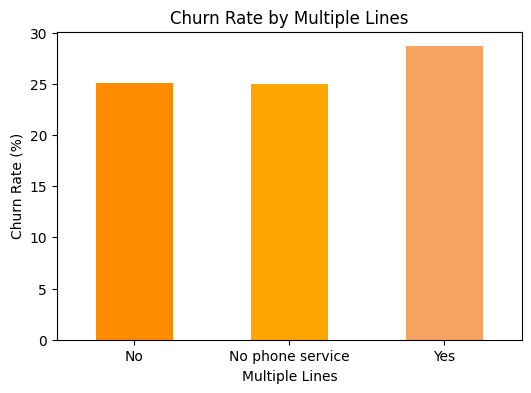

In [ ]:
# Visualize churn rate by Multiple Lines
plt.figure(figsize=(6, 4))
churn_rate_by_multiple_lines.plot(kind='bar', color=['darkorange', 'orange', 'sandybrown'])
plt.title('Churn Rate by Multiple Lines')
plt.xlabel('Multiple Lines')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Calculate churn rate by Internet Service
churn_by_internet_service = telco.groupby('InternetService')['Churn'].mean() * 100
print("Churn Rate by Internet Service:")
print(churn_by_internet_service)

Churn Rate by Internet Service:
InternetService
DSL            18.998344
Fiber optic    41.892765
No              7.434211
Name: Churn, dtype: float64


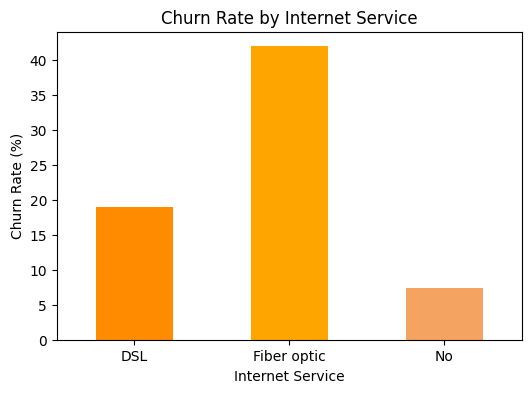

In [ ]:
# Visualize churn rate by Internet Service
plt.figure(figsize=(6, 4))
churn_by_internet_service.plot(kind='bar', color=['darkorange', 'orange', 'sandybrown'])
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

Highest Churn of Fibre optic.

/tmp/ipython-input-4107455735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=telco, palette='Oranges')


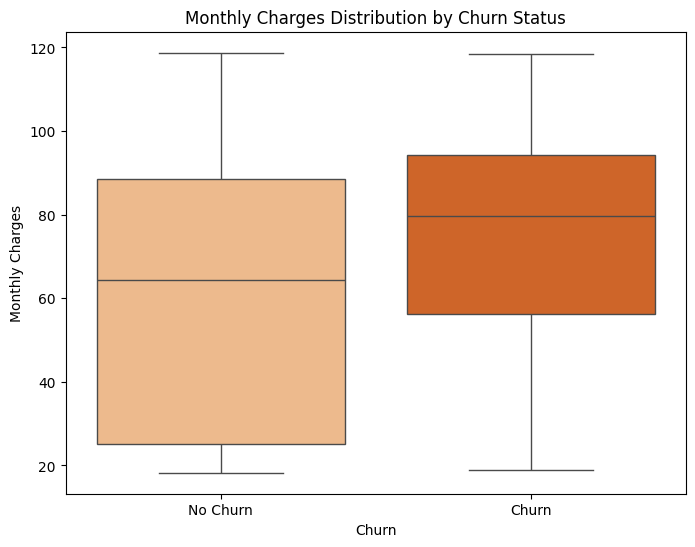

In [ ]:
# Compare Monthly Charges for churned and non-churned customers
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=telco, palette='Oranges')
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])

plt.show()

Churn Rate by Tenure Cohort:

In [ ]:
# Create tenure-based cohorts
bins = [0, 12, 24, 48, 72]  # group by months of tenure
labels = ['0–12 months', '13–24 months', '25–48 months', '49–72 months']
telco['TenureGroup'] = pd.cut(telco['tenure'], bins=bins, labels=labels, right=True)

In [ ]:
# Calculate churn rate per cohort
cohort_churn = telco.groupby('TenureGroup')['Churn'].mean() * 100
print(cohort_churn)

TenureGroup
0–12 months     47.678161
13–24 months    28.710938
25–48 months    20.388959
49–72 months     9.513176
Name: Churn, dtype: float64


/tmp/ipython-input-809782807.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_churn = telco.groupby('TenureGroup')['Churn'].mean() * 100


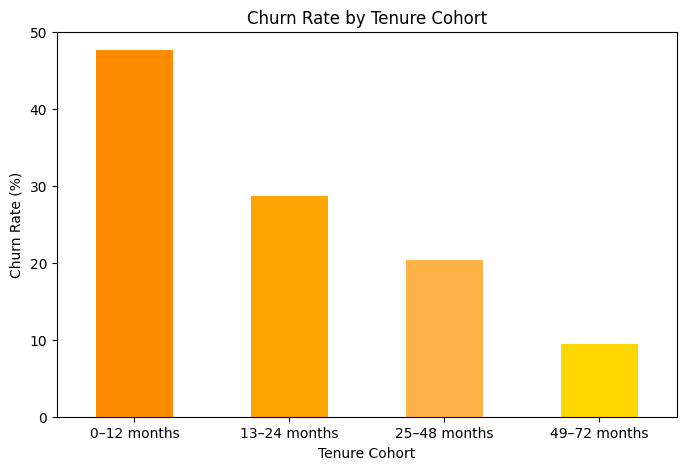

In [ ]:
# Plot cohort churn rate
plt.figure(figsize=(8,5))
colors = ['#FF8C00', '#FFA500', '#FFB347', '#FFD700']
cohort_churn.plot(kind='bar', color=colors)
plt.title('Churn Rate by Tenure Cohort')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Cohort')
plt.xticks(rotation=0)
plt.show()

Churn rate by Contract Type:

In [ ]:
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,num_addon_services,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,No phone serviceNoYesNoNoNoNo,0–12 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,0,NoYesNoYesNoNoNo,25–48 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,NoYesYesNoNoNoNo,0–12 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,No phone serviceYesNoYesYesNoNo,25–48 months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,NoNoNoNoNoNoNo,0–12 months


In [ ]:
# Calculate churn rate by Contract Type
churn_by_contract = telco.groupby('Contract')['Churn'].mean() * 100
print("Churn Rate by Contract Type:")
print(churn_by_contract)

Churn Rate by Contract Type:
Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


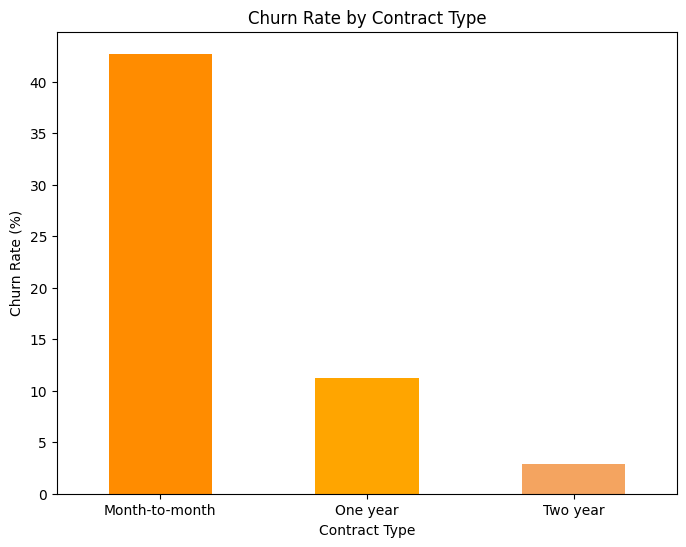

In [ ]:
# Visualize churn rate by Contract Type
plt.figure(figsize=(8, 6))
churn_by_contract.plot(kind='bar', color=['darkorange', 'orange', 'sandybrown'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Group by TenureGroup and Contract and count the occurrences
contract_by_tenure = telco.groupby(['TenureGroup', 'Contract'], observed=False).size().unstack(fill_value=0)

# Find the most popular contract type for each TenureGroup
most_popular_contract = contract_by_tenure.idxmax(axis=1)
print("Most popular contract type by Tenure Cohort:")
print(most_popular_contract)

Most popular contract type by Tenure Cohort:
TenureGroup
0–12 months     Month-to-month
13–24 months    Month-to-month
25–48 months    Month-to-month
49–72 months          Two year
dtype: object


Churn rate by Payment Methods:

In [ ]:
# Calculate churn rate by Payment Method
churn_by_payment_method = telco.groupby('PaymentMethod')['Churn'].mean() * 100
print("Churn Rate by Payment Method:")
print(churn_by_payment_method)

Churn Rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Electronic check             45.285412
Mailed check                 19.201995
Name: Churn, dtype: float64


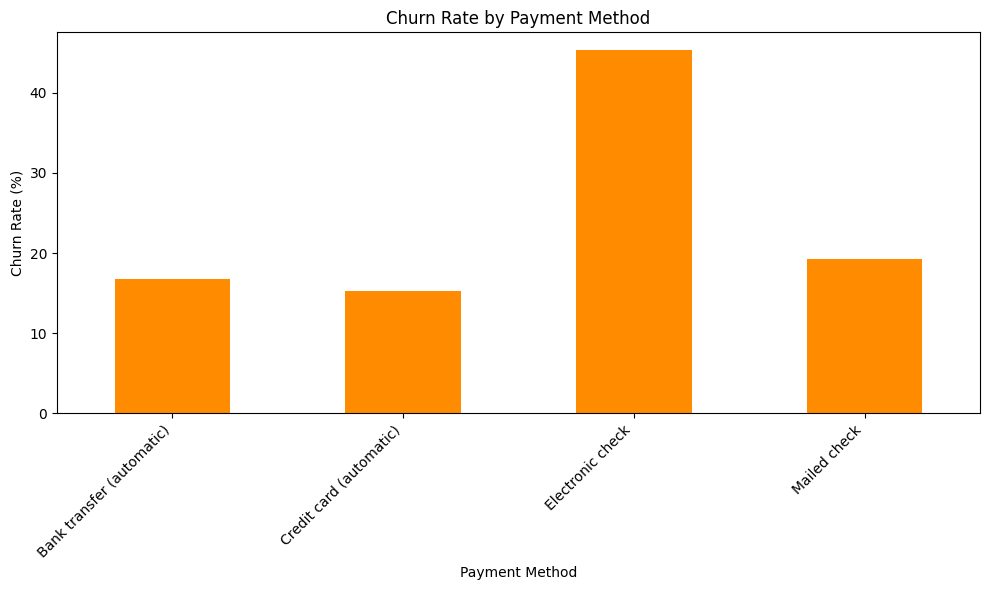

In [ ]:
# Visualize churn rate by Payment Method
plt.figure(figsize=(10, 6))
churn_by_payment_method.plot(kind='bar', color='darkorange')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Churn rate by Paperless Billing:

In [ ]:
# Calculate churn rate by Paperless Billing
churn_by_paperless_billing = telco.groupby('PaperlessBilling')['Churn'].mean() * 100
print("Churn Rate by Paperless Billing:")
print(churn_by_paperless_billing)

Churn Rate by Paperless Billing:
PaperlessBilling
No     16.375698
Yes    33.589251
Name: Churn, dtype: float64


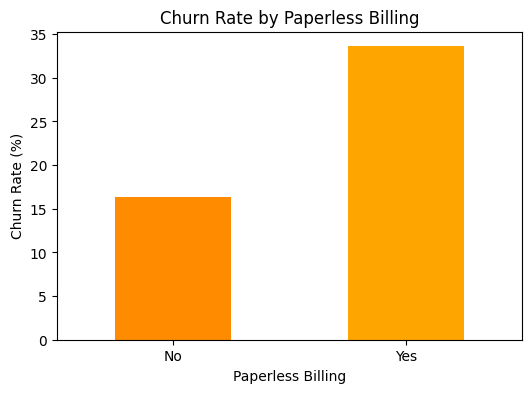

In [ ]:
# Visualize churn rate by Paperless Billing
plt.figure(figsize=(6, 4))
churn_by_paperless_billing.plot(kind='bar', color=['darkorange', 'orange'])
plt.title('Churn Rate by Paperless Billing')
plt.xlabel('Paperless Billing')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

# 3. Feature Engineering

3.1. Data Encoding

In [ ]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customerID          7032 non-null   object  
 1   gender              7032 non-null   object  
 2   SeniorCitizen       7032 non-null   int64   
 3   Partner             7032 non-null   object  
 4   Dependents          7032 non-null   object  
 5   tenure              7032 non-null   int64   
 6   PhoneService        7032 non-null   object  
 7   MultipleLines       7032 non-null   object  
 8   InternetService     7032 non-null   object  
 9   OnlineSecurity      7032 non-null   object  
 10  OnlineBackup        7032 non-null   object  
 11  DeviceProtection    7032 non-null   object  
 12  TechSupport         7032 non-null   object  
 13  StreamingTV         7032 non-null   object  
 14  StreamingMovies     7032 non-null   object  
 15  Contract            7032 non-null   object 

In [ ]:
# Drop num_addon_services and TenureGroup
telco = telco.drop(['customerID', 'num_addon_services', 'TenureGroup'], axis=1)

In [ ]:
# Label encoding for binary variables
binary_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
telco[binary_columns] = telco[binary_columns].replace({'Yes': 1, 'No': 0})


/tmp/ipython-input-2035112645.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telco[binary_columns] = telco[binary_columns].replace({'Yes': 1, 'No': 0})


In [ ]:
telco['gender'] = telco['gender'].map({'Male': 1, 'Female': 0})

In [ ]:
add_on_services = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']

# Map Yes: 1, No/No internet service: 0
telco[add_on_services] = telco[add_on_services].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

/tmp/ipython-input-2304631009.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telco[add_on_services] = telco[add_on_services].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})


In [ ]:
# One-hot encoding for multi-categories variables
multi_category_columns = ['InternetService', 'Contract', 'PaymentMethod']
# Apply one-hot encoding and drop the first category to avoid dummy variable trap
telco = pd.get_dummies(telco, columns=multi_category_columns, drop_first=True)

In [ ]:
telco.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


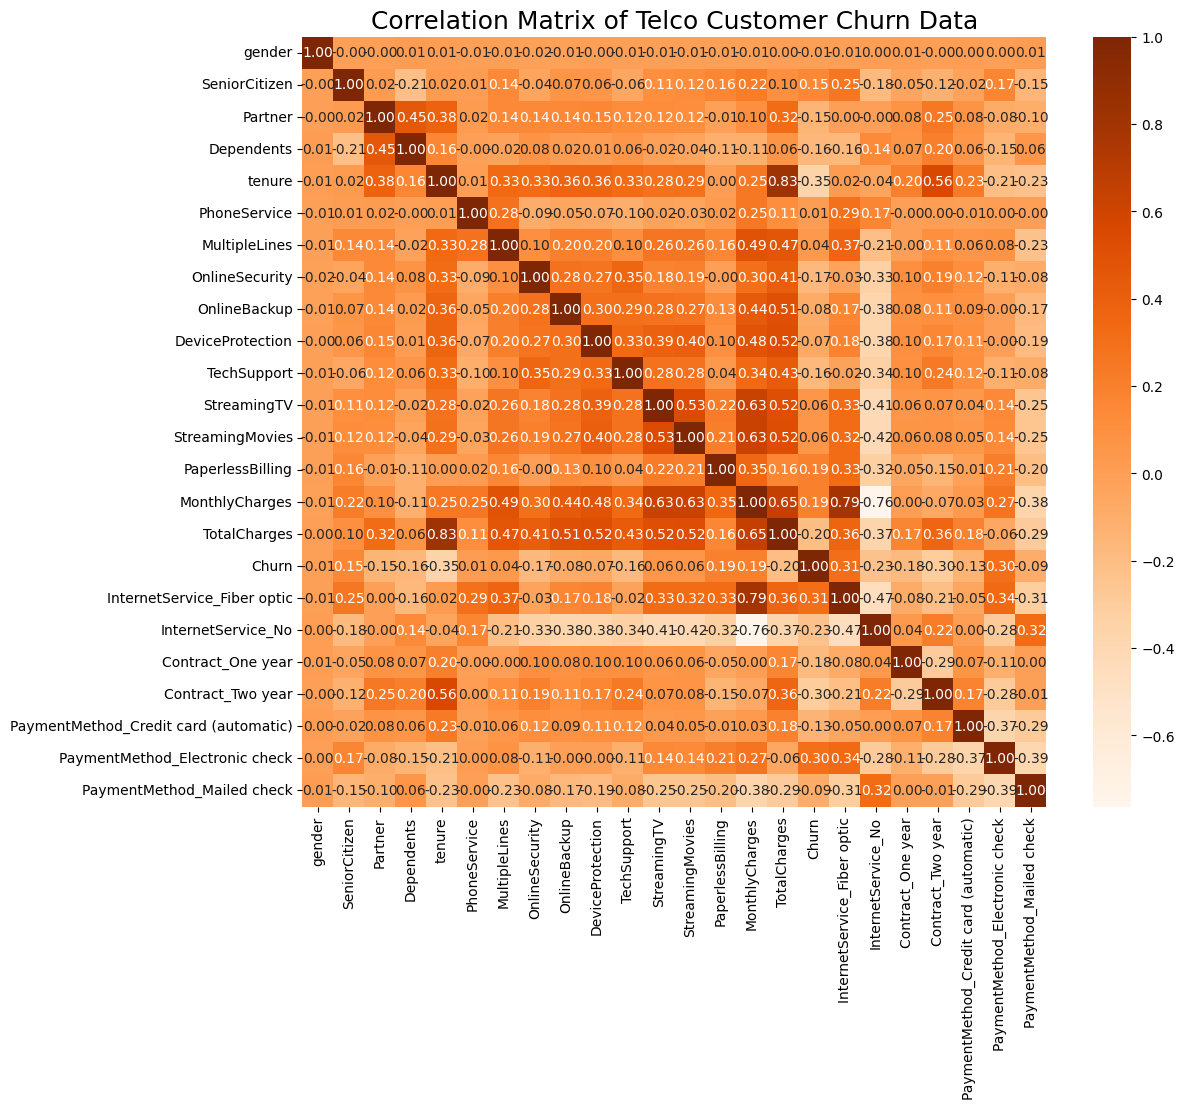

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(telco.corr(numeric_only=True), annot=True, cmap='Oranges', fmt='.2f')
plt.title('Correlation Matrix of Telco Customer Churn Data', fontsize=18)
plt.xticks
plt.yticks
plt.show()

3.2. Variance Inflation Factor (VIF)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Drop 'Churn' column as it's not a feature
X = telco.drop(['Churn'], axis=1)

# Convert boolean columns to numeric (0 and 1)
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# Add constant term for VIF calculation
X = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF values
print(vif_data.sort_values(by='VIF', ascending=True))

                                  feature         VIF
1                                  gender    1.002106
2                           SeniorCitizen    1.153220
14                       PaperlessBilling    1.208455
4                              Dependents    1.381598
3                                 Partner    1.462988
21  PaymentMethod_Credit card (automatic)    1.560999
19                      Contract_One year    1.625784
23             PaymentMethod_Mailed check    1.857058
22         PaymentMethod_Electronic check    1.976032
20                      Contract_Two year    2.652328
8                          OnlineSecurity    6.338349
11                            TechSupport    6.476508
9                            OnlineBackup    6.796678
10                       DeviceProtection    6.924754
7                           MultipleLines    7.289761
5                                  tenure    7.584453
16                           TotalCharges   10.811490
12                          

In [ ]:
# Drop the MonthlyCharges column
telco = telco.drop('MonthlyCharges', axis=1)

In [ ]:
# Drop the InternetService_No column
telco = telco.drop(columns=[ 'InternetService_No'])

In [ ]:
# Drop the StreamingMovies columns
telco = telco.drop(columns=['StreamingMovies'])

In [ ]:
# Drop the PhoneService column
telco = telco.drop(columns=['PhoneService'])

In [ ]:
X = telco.drop(['Churn'], axis=1)
y = telco['Churn']

# Convert boolean columns to numeric (0 and 1)
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# Add constant term for VIF calculation
X_vif = add_constant(X.copy())

# Recalculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data.sort_values(by='VIF', ascending=True))

                                  feature        VIF
1                                  gender   1.001654
2                           SeniorCitizen   1.148052
12                       PaperlessBilling   1.188915
7                          OnlineSecurity   1.347665
4                              Dependents   1.379535
6                           MultipleLines   1.393825
8                            OnlineBackup   1.413391
10                            TechSupport   1.438418
3                                 Partner   1.462368
9                        DeviceProtection   1.477984
17  PaymentMethod_Credit card (automatic)   1.560874
15                      Contract_One year   1.562125
11                            StreamingTV   1.586619
19             PaymentMethod_Mailed check   1.826284
18         PaymentMethod_Electronic check   1.959277
14            InternetService_Fiber optic   2.193362
16                      Contract_Two year   2.458387
5                                  tenure   6.

3.3. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Define predictors and target
X = telco.drop('Churn', axis=1)
y = telco['Churn']

# Split into 70% train 30% test (STRATIFIED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train), " | Test size:", len(X_test))
print("Churn ratio (Train):", round(y_train.mean(), 3))
print("Churn ratio (Test):", round(y_test.mean(), 3))


Train size: 4922  | Test size: 2110
Churn ratio (Train): 0.266
Churn ratio (Test): 0.266


3.4. Data Standardization

In [ ]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Identify numeric columns to scale
numerical_columns = ['tenure', 'TotalCharges']

scaler = StandardScaler()

# Fit only on TRAIN, then transform both TRAIN and TEST
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns].copy())
X_test[numerical_columns]  = scaler.transform(X_test[numerical_columns].copy())

print("Scaled numerical columns verified (Train):")
print(X_train[numerical_columns].describe().round(2))

Scaled numerical columns verified (Train):
        tenure  TotalCharges
count  4922.00       4922.00
mean      0.00          0.00
std       1.00          1.00
min      -1.28         -1.00
25%      -0.96         -0.83
50%      -0.14         -0.39
75%       0.96          0.66
max       1.61          2.81


3.5. Stratified 5-fold Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Define 5-fold stratified CV on train set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    print(f"Fold {fold+1}: Train={len(train_idx)}, Validate={len(val_idx)}")

Fold 1: Train=3937, Validate=985
Fold 2: Train=3937, Validate=985
Fold 3: Train=3938, Validate=984
Fold 4: Train=3938, Validate=984
Fold 5: Train=3938, Validate=984


# 4. Model Building (Baseline Validation Performance)

4.1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# Initialize the Logistic Regression model with class weights set to 'balanced'
logistic_model = LogisticRegression(random_state=42, class_weight='balanced')

# --- Cross-validation on Training Data ---
print("--- Performing 5-fold Cross-validation on Training Data ---")

cv_accuracy_scores = cross_val_score(logistic_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_precision_scores = cross_val_score(logistic_model, X_train, y_train, cv=cv, scoring='precision')
cv_recall_scores = cross_val_score(logistic_model, X_train, y_train, cv=cv, scoring='recall')
cv_f1_scores = cross_val_score(logistic_model, X_train, y_train, cv=cv, scoring='f1')
cv_roc_auc_scores = cross_val_score(logistic_model, X_train, y_train, cv=cv, scoring='roc_auc')


print("\nCross-validation Scores:")
print(f"Accuracy: {cv_accuracy_scores.mean():.4f} (+/- {cv_accuracy_scores.std() * 2:.4f})")
print(f"Precision: {cv_precision_scores.mean():.4f} (+/- {cv_precision_scores.std() * 2:.4f})")
print(f"Recall: {cv_recall_scores.mean():.4f} (+/- {cv_recall_scores.std() * 2:.4f})")
print(f"F1 Score: {cv_f1_scores.mean():.4f} (+/- {cv_f1_scores.std() * 2:.4f})")
print(f"ROC-AUC: {cv_roc_auc_scores.mean():.4f} (+/- {cv_roc_auc_scores.std() * 2:.4f})")


# --- Training on Full Training Data and Evaluation on Test Data ---
print("\n--- Training on Full Training Data and Evaluating on Test Data ---")

# Train the model on the entire training set
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Get predicted probabilities for ROC-AUC calculation
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

# Evaluate the model on the test set
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)


print("\nLogistic Regression Model Evaluation on Test Set (with class weights):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


# Print classification report and confusion matrix
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_pred))

--- Performing 5-fold Cross-validation on Training Data ---

Cross-validation Scores:
Accuracy: 0.7395 (+/- 0.0196)
Precision: 0.5064 (+/- 0.0224)
Recall: 0.8180 (+/- 0.0196)
F1 Score: 0.6255 (+/- 0.0194)
ROC-AUC: 0.8411 (+/- 0.0285)

--- Training on Full Training Data and Evaluating on Test Data ---

Logistic Regression Model Evaluation on Test Set (with class weights):
Accuracy: 0.7265
Precision: 0.4914
Recall: 0.8146
F1 Score: 0.6130
ROC-AUC: 0.8340

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1549
           1       0.49      0.81      0.61       561

    accuracy                           0.73      2110
   macro avg       0.70      0.75      0.70      2110
weighted avg       0.80      0.73      0.74      2110


Confusion Matrix on Test Set:
[[1076  473]
 [ 104  457]]


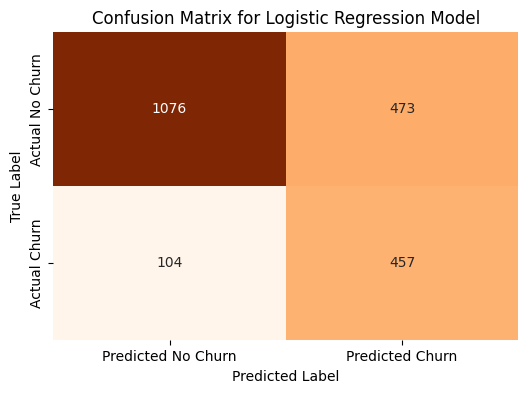

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

4.2. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# Initialize the Decision Tree model with class weights set to 'balanced'
decision_tree_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# --- Cross-validation on Training Data ---
print("--- Performing 5-fold Cross-validation on Training Data ---")

cv_accuracy_scores_dt = cross_val_score(decision_tree_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_precision_scores_dt = cross_val_score(decision_tree_model, X_train, y_train, cv=cv, scoring='precision')
cv_recall_scores_dt = cross_val_score(decision_tree_model, X_train, y_train, cv=cv, scoring='recall')
cv_f1_scores_dt = cross_val_score(decision_tree_model, X_train, y_train, cv=cv, scoring='f1')
cv_roc_auc_scores_dt = cross_val_score(decision_tree_model, X_train, y_train, cv=cv, scoring='roc_auc')

print("\nCross-validation Scores:")
print(f"Accuracy: {cv_accuracy_scores_dt.mean():.4f} (+/- {cv_accuracy_scores_dt.std() * 2:.4f})")
print(f"Precision: {cv_precision_scores_dt.mean():.4f} (+/- {cv_precision_scores_dt.std() * 2:.4f})")
print(f"Recall: {cv_recall_scores_dt.mean():.4f} (+/- {cv_recall_scores_dt.std() * 2:.4f})")
print(f"F1 Score: {cv_f1_scores_dt.mean():.4f} (+/- {cv_f1_scores_dt.std() * 2:.4f})")
print(f"ROC-AUC: {cv_roc_auc_scores_dt.mean():.4f} (+/- {cv_roc_auc_scores_dt.std() * 2:.4f})")

# --- Training on Full Training Data and Evaluation on Test Data ---
print("\n--- Training on Full Training Data and Evaluating on Test Data ---")

# Train the model on the entire training set
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Get predicted probabilities for ROC-AUC calculation
y_pred_proba_dt = decision_tree_model.predict_proba(X_test)[:, 1]

# Evaluate the model on the test set
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print("\nDecision Tree Model Evaluation on Test Set (with class weights):")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1 Score: {f1_dt:.4f}")
print(f"ROC-AUC: {roc_auc_dt:.4f}")

# Print classification report and confusion matrix
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_pred_dt))

--- Performing 5-fold Cross-validation on Training Data ---

Cross-validation Scores:
Accuracy: 0.7430 (+/- 0.0183)
Precision: 0.5175 (+/- 0.0372)
Recall: 0.5122 (+/- 0.0474)
F1 Score: 0.5143 (+/- 0.0248)
ROC-AUC: 0.6695 (+/- 0.0157)

--- Training on Full Training Data and Evaluating on Test Data ---

Decision Tree Model Evaluation on Test Set (with class weights):
Accuracy: 0.7171
Precision: 0.4682
Recall: 0.4724
F1 Score: 0.4703
ROC-AUC: 0.6392

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1549
           1       0.47      0.47      0.47       561

    accuracy                           0.72      2110
   macro avg       0.64      0.64      0.64      2110
weighted avg       0.72      0.72      0.72      2110


Confusion Matrix on Test Set:
[[1248  301]
 [ 296  265]]


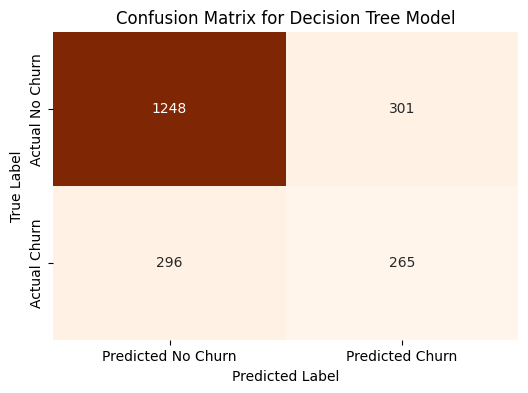

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree Model')
plt.show()

4.3. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# Initialize the Random Forest model with class weights set to 'balanced'
random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# --- Cross-validation on Training Data ---
print("--- Performing 5-fold Cross-validation on Training Data ---")

cv_accuracy_scores_rf = cross_val_score(random_forest_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_precision_scores_rf = cross_val_score(random_forest_model, X_train, y_train, cv=cv, scoring='precision')
cv_recall_scores_rf = cross_val_score(random_forest_model, X_train, y_train, cv=cv, scoring='recall')
cv_f1_scores_rf = cross_val_score(random_forest_model, X_train, y_train, cv=cv, scoring='f1')
cv_roc_auc_scores_rf = cross_val_score(random_forest_model, X_train, y_train, cv=cv, scoring='roc_auc')

print("\nCross-validation Scores:")
print(f"Accuracy: {cv_accuracy_scores_rf.mean():.4f} (+/- {cv_accuracy_scores_rf.std() * 2:.4f})")
print(f"Precision: {cv_precision_scores_rf.mean():.4f} (+/- {cv_precision_scores_rf.std() * 2:.4f})")
print(f"Recall: {cv_recall_scores_rf.mean():.4f} (+/- {cv_recall_scores_rf.std() * 2:.4f})")
print(f"F1 Score: {cv_f1_scores_rf.mean():.4f} (+/- {cv_f1_scores_rf.std() * 2:.4f})")
print(f"ROC-AUC: {cv_roc_auc_scores_rf.mean():.4f} (+/- {cv_roc_auc_scores_rf.std() * 2:.4f})")


# --- Training on Full Training Data and Evaluation on Test Data ---
print("\n--- Training on Full Training Data and Evaluating on Test Data ---")

# Train the model on the entire training set
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Get predicted probabilities for ROC-AUC calculation
y_pred_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Evaluate the model on the test set
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("\nRandom Forest Model Evaluation on Test Set (with class weights):")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")


# Print classification report and confusion matrix
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_pred_rf))

--- Performing 5-fold Cross-validation on Training Data ---

Cross-validation Scores:
Accuracy: 0.7840 (+/- 0.0236)
Precision: 0.6314 (+/- 0.0655)
Recall: 0.4511 (+/- 0.0611)
F1 Score: 0.5258 (+/- 0.0575)
ROC-AUC: 0.8223 (+/- 0.0284)

--- Training on Full Training Data and Evaluating on Test Data ---

Random Forest Model Evaluation on Test Set (with class weights):
Accuracy: 0.7820
Precision: 0.6241
Recall: 0.4528
F1 Score: 0.5248
ROC-AUC: 0.8065

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.62      0.45      0.52       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.69      2110
weighted avg       0.77      0.78      0.77      2110


Confusion Matrix on Test Set:
[[1396  153]
 [ 307  254]]


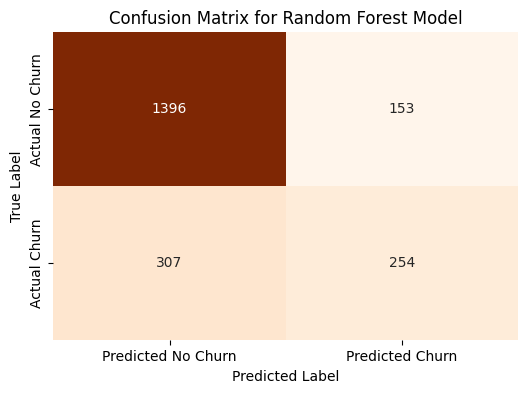

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

4.4. XG Boost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# Initialize the XGBoost classifier
# Use scale_pos_weight to handle class imbalance
# scale_pos_weight = count(negative class) / count(positive class)
scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])


xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',
                              scale_pos_weight=scale_pos_weight_value)


# --- Cross-validation on Training Data ---
print("--- Performing 5-fold Cross-validation on Training Data ---")


cv_accuracy_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_precision_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='precision')
cv_recall_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='recall')
cv_f1_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='f1')
cv_roc_auc_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')

print("\nCross-validation Scores:")
print(f"Accuracy: {cv_accuracy_scores_xgb.mean():.4f} (+/- {cv_accuracy_scores_xgb.std() * 2:.4f})")
print(f"Precision: {cv_precision_scores_xgb.mean():.4f} (+/- {cv_precision_scores_xgb.std() * 2:.4f})")
print(f"Recall: {cv_recall_scores_xgb.mean():.4f} (+/- {cv_recall_scores_xgb.std() * 2:.4f})")
print(f"F1 Score: {cv_f1_scores_xgb.mean():.4f} (+/- {cv_f1_scores_xgb.std() * 2:.4f})")
print(f"ROC-AUC: {cv_roc_auc_scores_xgb.mean():.4f} (+/- {cv_roc_auc_scores_xgb.std() * 2:.4f})")


# --- Training on Full Training Data and Evaluation on Test Data ---
print("\n--- Training on Full Training Data and Evaluating on Test Data ---")

# Train the model on the entire training set
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Get predicted probabilities for ROC-AUC calculation
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model on the test set
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)


print("\nXGBoost Model Evaluation on Test Set:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")

# Print classification report and confusion matrix
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_pred_xgb))

--- Performing 5-fold Cross-validation on Training Data ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:46:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:46:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:46:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:46:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:46:28] WARNING: /w


Cross-validation Scores:
Accuracy: 0.7619 (+/- 0.0347)
Precision: 0.5428 (+/- 0.0561)
Recall: 0.6674 (+/- 0.0603)
F1 Score: 0.5985 (+/- 0.0531)
ROC-AUC: 0.8234 (+/- 0.0348)

--- Training on Full Training Data and Evaluating on Test Data ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:46:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Model Evaluation on Test Set:
Accuracy: 0.7512
Precision: 0.5252
Recall: 0.6684
F1 Score: 0.5882
ROC-AUC: 0.8087

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1549
           1       0.53      0.67      0.59       561

    accuracy                           0.75      2110
   macro avg       0.70      0.72      0.70      2110
weighted avg       0.78      0.75      0.76      2110


Confusion Matrix on Test Set:
[[1210  339]
 [ 186  375]]


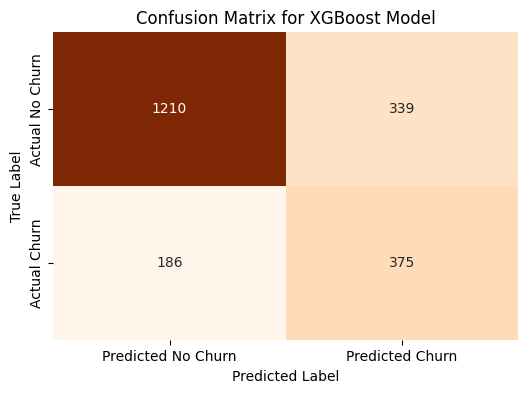

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost Model')
plt.show()

In [ ]:
# Create a dictionary to store the evaluation metrics for each model
model_performance = {
    'Logistic Regression': {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    },
    'Decision Tree': {
        'Accuracy': accuracy_dt,
        'Precision': precision_dt,
        'Recall': recall_dt,
        'F1 Score': f1_dt,
        'ROC-AUC': roc_auc_dt
    },
    'Random Forest': {
        'Accuracy': accuracy_rf,
        'Precision': precision_rf,
        'Recall': recall_rf,
        'F1 Score': f1_rf,
        'ROC-AUC': roc_auc_rf
    },
    'XGBoost': {
        'Accuracy': accuracy_xgb,
        'Precision': precision_xgb,
        'Recall': recall_xgb,
        'F1 Score': f1_xgb,
        'ROC-AUC': roc_auc_xgb
    }
}

# Convert the dictionary to a pandas DataFrame for easy comparison
performance_df = pd.DataFrame.from_dict(model_performance, orient='index')

# Display the performance comparison table
print("Model Performance Comparison on Test Set:")
display(performance_df)

Model Performance Comparison on Test Set:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.726540,0.491398,0.814617,0.613011,0.833986
Decision Tree,0.717062,0.468198,0.472371,0.470275,0.639158
Random Forest,0.781991,0.624079,0.452763,0.524793,0.806465
XGBoost,0.751185,0.525210,0.668449,0.588235,0.808704


* Logistic Regression and XGBoost show strong performance in Recall, F1 Score, and ROC-AUC, making them good at identifying churners.
* Random Forest excels in overall Accuracy and Precision, being more reliable when it predicts churn.
* The Decision Tree is less performant compared to the others.


Models that perform well on relevant metrics and show potential for improvement are worth tuning. In this case, Logistic Regression, Random Forest, and XGBoost are the top contenders for hyperparameter tuning as they demonstrated the best results and have complex enough structures to benefit from optimization.



# 5. Model Tuned Performance

5.1. Tuned Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np

# Define the hyperparameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100], # Inverse of regularization strength
    'solver': ['liblinear', 'lbfgs'],   # Algorithm to use in the optimization problem
    'penalty': ['l1', 'l2'],          # Specify the norm of the penalty
    'class_weight': [None, 'balanced'] # Weights associated with classes
}

# Adjust param_grid to include only valid combinations of penalty and solver
# 'l1' penalty is only supported by 'liblinear' solver
param_grid_adjusted_lr = []
for c in param_grid_lr['C']:
    for cw in param_grid_lr['class_weight']:
        # liblinear supports l1 and l2
        param_grid_adjusted_lr.append({'C': [c], 'solver': ['liblinear'], 'penalty': ['l1'], 'class_weight': [cw]})
        param_grid_adjusted_lr.append({'C': [c], 'solver': ['liblinear'], 'penalty': ['l2'], 'class_weight': [cw]})
        # lbfgs supports l2
        param_grid_adjusted_lr.append({'C': [c], 'solver': ['lbfgs'], 'penalty': ['l2'], 'class_weight': [cw]})


print("Adjusted Hyperparameter Grid for Logistic Regression:")
print(param_grid_adjusted_lr)

Adjusted Hyperparameter Grid for Logistic Regression:
[{'C': [0.001], 'solver': ['liblinear'], 'penalty': ['l1'], 'class_weight': [None]}, {'C': [0.001], 'solver': ['liblinear'], 'penalty': ['l2'], 'class_weight': [None]}, {'C': [0.001], 'solver': ['lbfgs'], 'penalty': ['l2'], 'class_weight': [None]}, {'C': [0.001], 'solver': ['liblinear'], 'penalty': ['l1'], 'class_weight': ['balanced']}, {'C': [0.001], 'solver': ['liblinear'], 'penalty': ['l2'], 'class_weight': ['balanced']}, {'C': [0.001], 'solver': ['lbfgs'], 'penalty': ['l2'], 'class_weight': ['balanced']}, {'C': [0.01], 'solver': ['liblinear'], 'penalty': ['l1'], 'class_weight': [None]}, {'C': [0.01], 'solver': ['liblinear'], 'penalty': ['l2'], 'class_weight': [None]}, {'C': [0.01], 'solver': ['lbfgs'], 'penalty': ['l2'], 'class_weight': [None]}, {'C': [0.01], 'solver': ['liblinear'], 'penalty': ['l1'], 'class_weight': ['balanced']}, {'C': [0.01], 'solver': ['liblinear'], 'penalty': ['l2'], 'class_weight': ['balanced']}, {'C': [0

In [ ]:
from sklearn.model_selection import GridSearchCV

# Initialize a Logistic Regression model
logistic_model_grid = LogisticRegression(random_state=42)

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=logistic_model_grid,
    param_grid=param_grid_adjusted_lr,
    cv=cv,  # Use the StratifiedKFold object defined earlier
    scoring='roc_auc', # Use ROC-AUC as the scoring metric for tuning
    n_jobs=-1 # Use all available cores for faster computation
)

print("GridSearchCV initialized for Logistic Regression tuning.")

GridSearchCV initialized for Logistic Regression tuning.


In [ ]:
# Perform the hyperparameter search by fitting GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

print("Hyperparameter search for Logistic Regression complete.")

Hyperparameter search for Logistic Regression complete.


In [ ]:
# Get the best hyperparameters found by GridSearchCV
best_params_lr = grid_search_lr.best_params_
print("Best Hyperparameters for Logistic Regression:", best_params_lr)

# Get the best model (estimator) found by GridSearchCV
best_logistic_model = grid_search_lr.best_estimator_
print("\nBest Logistic Regression Model:")
print(best_logistic_model)

Best Hyperparameters for Logistic Regression: {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}

Best Logistic Regression Model:
LogisticRegression(C=1, penalty='l1', random_state=42, solver='liblinear')


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# Make predictions on the test set using the best tuned model
y_pred_tuned_lr = best_logistic_model.predict(X_test)

# Get predicted probabilities for ROC-AUC calculation
y_pred_proba_tuned_lr = best_logistic_model.predict_proba(X_test)[:, 1]

# Evaluate the tuned model on the test set
accuracy_tuned_lr = accuracy_score(y_test, y_pred_tuned_lr)
precision_tuned_lr = precision_score(y_test, y_pred_tuned_lr)
recall_tuned_lr = recall_score(y_test, y_pred_tuned_lr)
f1_tuned_lr = f1_score(y_test, y_pred_tuned_lr)
roc_auc_tuned_lr = roc_auc_score(y_test, y_pred_proba_tuned_lr)

print("Tuned Logistic Regression Model Evaluation on Test Set:")
print(f"Accuracy: {accuracy_tuned_lr:.4f}")
print(f"Precision: {precision_tuned_lr:.4f}")
print(f"Recall: {recall_tuned_lr:.4f}")
print(f"F1 Score: {f1_tuned_lr:.4f}")
print(f"ROC-AUC: {roc_auc_tuned_lr:.4f}")

# Print classification report and confusion matrix
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_tuned_lr))

print("\nConfusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_pred_tuned_lr))

Tuned Logistic Regression Model Evaluation on Test Set:
Accuracy: 0.7995
Precision: 0.6527
Recall: 0.5258
F1 Score: 0.5824
ROC-AUC: 0.8347

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.65      0.53      0.58       561

    accuracy                           0.80      2110
   macro avg       0.75      0.71      0.73      2110
weighted avg       0.79      0.80      0.79      2110


Confusion Matrix on Test Set:
[[1392  157]
 [ 266  295]]


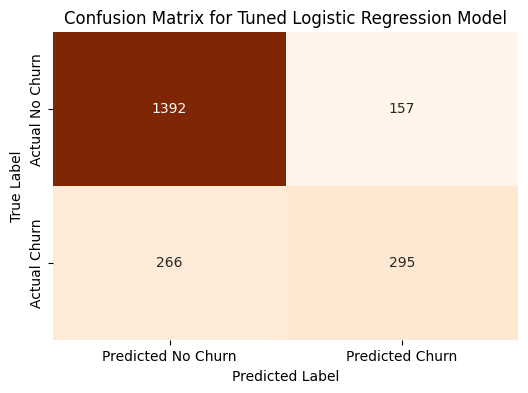

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the tuned Logistic Regression model
cm_tuned_lr = confusion_matrix(y_test, y_pred_tuned_lr)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned_lr, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned Logistic Regression Model')
plt.show()

5.2. Tuned Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

# Define the hyperparameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'class_weight': ['balanced', 'balanced_subsample'] # Weights for imbalanced classes
}

print("Random Forest Hyperparameter Grid:")
print(param_grid_rf)

Random Forest Hyperparameter Grid:
{'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'class_weight': ['balanced', 'balanced_subsample']}


In [ ]:
from sklearn.model_selection import GridSearchCV

# Initialize a Random Forest model
random_forest_model_grid = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=random_forest_model_grid,
    param_grid=param_grid_rf, # Use param_grid for GridSearchCV
    cv=cv,  # Use the StratifiedKFold object defined earlier
    scoring='roc_auc', # Use ROC-AUC as the scoring metric for tuning
    n_jobs=-1 # Use all available cores for faster computation
)

print("GridSearchCV initialized for Random Forest tuning.")

GridSearchCV initialized for Random Forest tuning.


In [ ]:
# Perform the hyperparameter search by fitting GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print("Hyperparameter search for Random Forest complete.")

Hyperparameter search for Random Forest complete.


In [ ]:
# Get the best hyperparameters found by GridSearchCV
best_params_rf = grid_search_rf.best_params_
print("Best Hyperparameters for Random Forest:", best_params_rf)

# Get the best model (estimator) found by GridSearchCV
best_random_forest_model = grid_search_rf.best_estimator_
print("\nBest Random Forest Model:")
print(best_random_forest_model)

Best Hyperparameters for Random Forest: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

Best Random Forest Model:
RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       min_samples_leaf=4, n_estimators=300, random_state=42)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# Make predictions on the test set using the best tuned model
y_pred_tuned_rf = best_random_forest_model.predict(X_test)

# Get predicted probabilities for ROC-AUC calculation
y_pred_proba_tuned_rf = best_random_forest_model.predict_proba(X_test)[:, 1]

# Evaluate the tuned model on the test set
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)
roc_auc_tuned_rf = roc_auc_score(y_test, y_pred_proba_tuned_rf)

print("Tuned Random Forest Model Evaluation on Test Set:")
print(f"Accuracy: {accuracy_tuned_rf:.4f}")
print(f"Precision: {precision_tuned_rf:.4f}")
print(f"Recall: {recall_tuned_rf:.4f}")
print(f"F1 Score: {f1_tuned_rf:.4f}")
print(f"ROC-AUC: {roc_auc_tuned_rf:.4f}")

# Print classification report and confusion matrix
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_tuned_rf))

print("\nConfusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_pred_tuned_rf))

Tuned Random Forest Model Evaluation on Test Set:
Accuracy: 0.7673
Precision: 0.5449
Recall: 0.7576
F1 Score: 0.6339
ROC-AUC: 0.8373

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1549
           1       0.54      0.76      0.63       561

    accuracy                           0.77      2110
   macro avg       0.72      0.76      0.73      2110
weighted avg       0.80      0.77      0.78      2110


Confusion Matrix on Test Set:
[[1194  355]
 [ 136  425]]


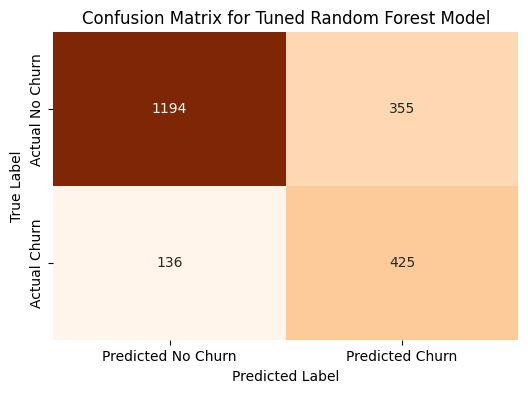

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the tuned Random Forest model
cm_tuned_rf = confusion_matrix(y_test, y_pred_tuned_rf)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned_rf, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned Random Forest Model')
plt.show()

5.3. Tuned XG Boost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

# Define the hyperparameter grid for XGBoost
# Changed to param_distributions for RandomizedSearchCV
param_distributions_xgb = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'max_depth': [3, 5, 7],         # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage used in update to prevent overfitting
    'subsample': [0.7, 0.8, 0.9],    # Subsample ratio of the training instances
    'colsample_bytree': [0.7, 0.8, 0.9], # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.2],          # Minimum loss reduction required to make a further partition on a leaf node
    'reg_alpha': [0, 0.1, 0.5],      # L1 regularization term on weights
    'reg_lambda': [0, 0.1, 0.5],     # L2 regularization term on weights
    'scale_pos_weight': [scale_pos_weight_value] # Handle class imbalance
}

print("XGBoost Hyperparameter Distributions:")
print(param_distributions_xgb)

XGBoost Hyperparameter Distributions:
{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.7, 0.8, 0.9], 'colsample_bytree': [0.7, 0.8, 0.9], 'gamma': [0, 0.1, 0.2], 'reg_alpha': [0, 0.1, 0.5], 'reg_lambda': [0, 0.1, 0.5], 'scale_pos_weight': [2.7629969418960245]}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Initialize an XGBoost model
xgb_model_grid = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Initialize RandomizedSearchCV instead of GridSearchCV
# n_iter controls the number of parameter settings that are sampled
# You can adjust this number based on your computational budget and desired search breadth
randomized_search_xgb = RandomizedSearchCV(
    estimator=xgb_model_grid,
    param_distributions=param_distributions_xgb, # Use param_distributions for RandomizedSearchCV
    n_iter=50,  # Number of parameter settings that are sampled
    cv=cv,  # Use the StratifiedKFold object defined earlier
    scoring='roc_auc', # Use ROC-AUC as the scoring metric for tuning
    random_state=42, # For reproducibility
    n_jobs=-1 # Use all available cores for faster computation
)

print("RandomizedSearchCV initialized for XGBoost tuning.")

RandomizedSearchCV initialized for XGBoost tuning.


In [ ]:
# Perform the hyperparameter search by fitting RandomizedSearchCV to the training data
randomized_search_xgb.fit(X_train, y_train)

print("Hyperparameter search for XGBoost complete.")

Hyperparameter search for XGBoost complete.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:04:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Get the best hyperparameters found by RandomizedSearchCV
best_params_xgb = randomized_search_xgb.best_params_
print("Best Hyperparameters for XGBoost:", best_params_xgb)

# Get the best model (estimator) found by RandomizedSearchCV
best_xgb_model = randomized_search_xgb.best_estimator_
print("\nBest XGBoost Model:")
print(best_xgb_model)

Best Hyperparameters for XGBoost: {'subsample': 0.7, 'scale_pos_weight': 2.7629969418960245, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}

Best XGBoost Model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_paral

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# Make predictions on the test set using the best tuned model
y_pred_tuned_xgb = best_xgb_model.predict(X_test)

# Get predicted probabilities for ROC-AUC calculation
y_pred_proba_tuned_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the tuned model on the test set
accuracy_tuned_xgb = accuracy_score(y_test, y_pred_tuned_xgb)
precision_tuned_xgb = precision_score(y_test, y_pred_tuned_xgb)
recall_tuned_xgb = recall_score(y_test, y_pred_tuned_xgb)
f1_tuned_xgb = f1_score(y_test, y_pred_tuned_xgb)
roc_auc_tuned_xgb = roc_auc_score(y_test, y_pred_proba_tuned_xgb)

print("Tuned XGBoost Model Evaluation on Test Set:")
print(f"Accuracy: {accuracy_tuned_xgb:.4f}")
print(f"Precision: {precision_tuned_xgb:.4f}")
print(f"Recall: {recall_tuned_xgb:.4f}")
print(f"F1 Score: {f1_tuned_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_tuned_xgb:.4f}")

# Print classification report and confusion matrix
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_tuned_xgb))

print("\nConfusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_pred_tuned_xgb))

Tuned XGBoost Model Evaluation on Test Set:
Accuracy: 0.7393
Precision: 0.5064
Recall: 0.7790
F1 Score: 0.6138
ROC-AUC: 0.8370

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1549
           1       0.51      0.78      0.61       561

    accuracy                           0.74      2110
   macro avg       0.70      0.75      0.71      2110
weighted avg       0.80      0.74      0.75      2110


Confusion Matrix on Test Set:
[[1123  426]
 [ 124  437]]


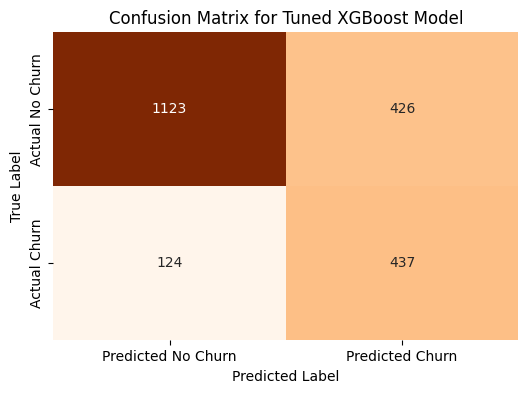

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm_tuned_xgb = confusion_matrix(y_test, y_pred_tuned_xgb)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned XGBoost Model')
plt.show()

In [ ]:
# Create a dictionary to store the evaluation metrics for each tuned model
tuned_model_performance = {
    'Tuned Logistic Regression': {
        'Accuracy': accuracy_tuned_lr,
        'Precision': precision_tuned_lr,
        'Recall': recall_tuned_lr,
        'F1 Score': f1_tuned_lr,
        'ROC-AUC': roc_auc_tuned_lr
    },
    'Tuned Random Forest': {
        'Accuracy': accuracy_tuned_rf,
        'Precision': precision_tuned_rf,
        'Recall': recall_tuned_rf,
        'F1 Score': f1_tuned_rf,
        'ROC-AUC': roc_auc_tuned_rf
    },
    'Tuned XGBoost': {
        'Accuracy': accuracy_tuned_xgb,
        'Precision': precision_tuned_xgb,
        'Recall': recall_tuned_xgb,
        'F1 Score': f1_tuned_xgb,
        'ROC-AUC': roc_auc_tuned_xgb
    }
}

# Convert the dictionary to a pandas DataFrame for easy comparison
tuned_performance_df = pd.DataFrame.from_dict(tuned_model_performance, orient='index')

# Display the performance comparison table
print("Tuned Model Performance Comparison on Test Set:")
display(tuned_performance_df)

Tuned Model Performance Comparison on Test Set:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Tuned Logistic Regression,0.799526,0.652655,0.525847,0.582428,0.834733
Tuned Random Forest,0.767299,0.544872,0.757576,0.633855,0.837287
Tuned XGBoost,0.739336,0.506373,0.778966,0.613764,0.837021


In [ ]:
import pandas as pd

# Combine the performance DataFrames
combined_performance_df = pd.concat([performance_df, tuned_performance_df])

print("Baseline vs. Tuned Model Performance Comparison on Test Set:")
display(combined_performance_df.round(4))

Baseline vs. Tuned Model Performance Comparison on Test Set:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.7265,0.4914,0.8146,0.6130,0.8340
Decision Tree,0.7171,0.4682,0.4724,0.4703,0.6392
Random Forest,0.7820,0.6241,0.4528,0.5248,0.8065
XGBoost,0.7512,0.5252,0.6684,0.5882,0.8087
Tuned Logistic Regression,0.7995,0.6527,0.5258,0.5824,0.8347
Tuned Random Forest,0.7673,0.5449,0.7576,0.6339,0.8373
Tuned XGBoost,0.7393,0.5064,0.7790,0.6138,0.8370


Based on the comparative evaluation of all models, the Tuned Random Forest emerges as the best-performing model for churn prediction. It provides the strongest balance across the most business-critical metrics, achieving the highest AUC (0.8373) and highest F1 score (0.6339) while maintaining strong recall (0.7576).

In [ ]:
import pandas as pd

# Get feature importances from the best tuned Random Forest model
feature_importances_rf = best_random_forest_model.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances_rf
})

# Sort the features by importance in descending order
top_features_rf = features_df.sort_values(by='Importance', ascending=False)

print("Top Features from Tuned Random Forest Model:")
display(top_features_rf)

Top Features from Tuned Random Forest Model:


,Feature,Importance
4,tenure,0.216886
12,TotalCharges,0.151850
13,InternetService_Fiber optic,0.134108
15,Contract_Two year,0.128015
17,PaymentMethod_Electronic check,0.069439
14,Contract_One year,0.057341
11,PaperlessBilling,0.033957
6,OnlineSecurity,0.024404
10,StreamingTV,0.022401
9,TechSupport,0.021990


/tmp/ipython-input-3122196170.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features_rf, palette='Oranges_r')


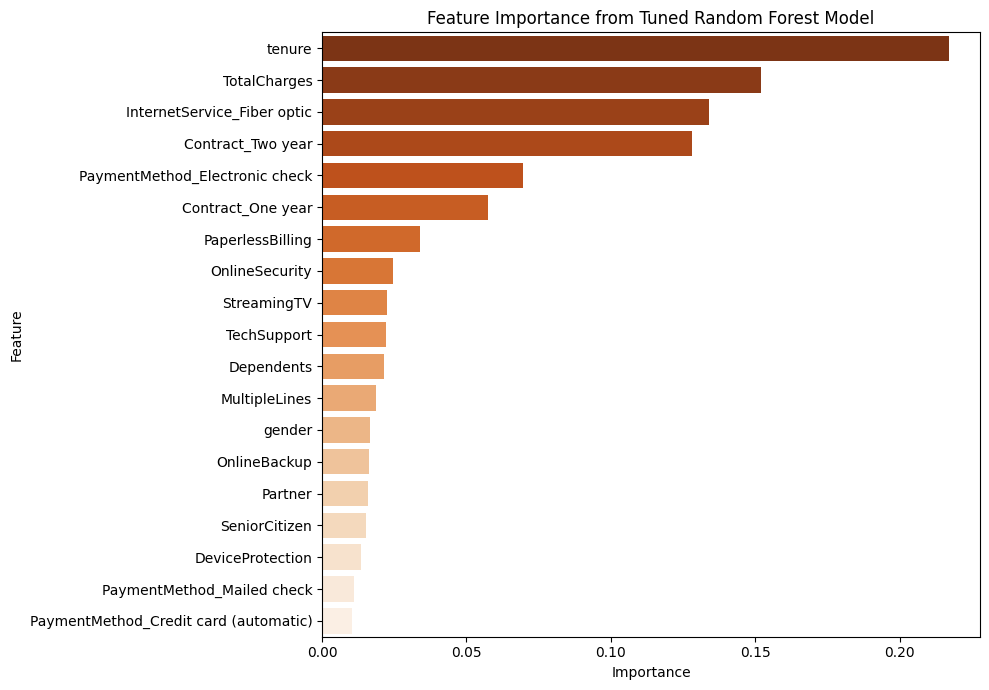

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the top features
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=top_features_rf, palette='Oranges_r')
plt.title('Feature Importance from Tuned Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

6. K-Means Clustering

In [ ]:
# Determine the optimal number of clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train, kmeans.labels_))

In [ ]:
# Plot both metrics side by side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)

plt.tight_layout()
plt.show()

Based on analyzing both the Elbow Method and the Silhouette Score plots, 4 clusters were selected as a practical compromise between minimizing within-cluster distance and maintaining a meaningful number of distinct groups for analysis.

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train)

# Add cluster labels to the training data
train_clustered = X_train.copy()
train_clustered['cluster'] = train_clusters
train_clustered['Churn'] = y_train

In [ ]:
# Analyze cluster characteristics
cluster_summary = train_clustered.groupby('cluster').mean()
print("Cluster Characteristics:")
display(cluster_summary)

# Calculate churn rate per cluster
churn_rate_per_cluster = train_clustered.groupby('cluster')['Churn'].mean()
print("\nChurn Rate per Cluster:")
display(churn_rate_per_cluster)

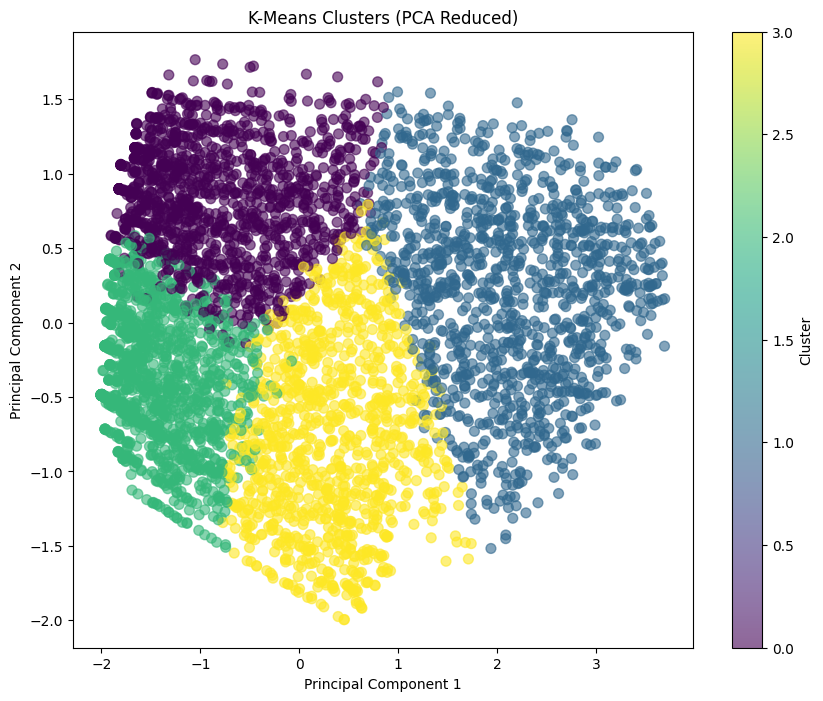

In [ ]:
from sklearn.decomposition import PCA

# Reduce dimensionality for visualization
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# Create a scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_clustered['cluster'], cmap='viridis', s=50, alpha=0.6)
plt.title('K-Means Clusters (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

4 distinct customer clusters were identified:

Cluster 0 (Highest Churn, 55.5%): medium tenure, Fiber Optic internet, month-to-month contracts, and electronic check payment.

Cluster 1 (Second Lowest Churn, 15.5%): Longest tenure, high add-on adoption, and longer-term contracts.

Cluster 2 (Medium Churn, 24.2%): Shortest tenure, basic services, and primarily month-to-month contracts.

Cluster 3 (Lowest Churn, 7.2%): Very long tenure, high proportion of two-year contracts, and stable payment methods.